# Exploratory Data Analysis (EDA)
## Indian Personal Finance and Spending Habits Dataset

This notebook performs exploratory data analysis to understand income, expenses,
savings behavior, and demographic patterns of individuals in India.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [6]:
df = pd.read_csv("C:\\Users\\katta\\Downloads\\data (1).csv")

# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()

,income,age,dependents,occupation,city_tier,rent,loan_repayment,insurance,groceries,transport,...,desired_savings,disposable_income,potential_savings_groceries,potential_savings_transport,potential_savings_eating_out,potential_savings_entertainment,potential_savings_utilities,potential_savings_healthcare,potential_savings_education,potential_savings_miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


#### Dataset overview

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   income                           20000 non-null  float64
 1   age                              20000 non-null  int64  
 2   dependents                       20000 non-null  int64  
 3   occupation                       20000 non-null  object 
 4   city_tier                        20000 non-null  object 
 5   rent                             20000 non-null  float64
 6   loan_repayment                   20000 non-null  float64
 7   insurance                        20000 non-null  float64
 8   groceries                        20000 non-null  float64
 9   transport                        20000 non-null  float64
 10  eating_out                       20000 non-null  float64
 11  entertainment                    20000 non-null  float64
 12  utilities         

In [8]:
df.describe()

,income,age,dependents,rent,loan_repayment,insurance,groceries,transport,eating_out,entertainment,...,desired_savings,disposable_income,potential_savings_groceries,potential_savings_transport,potential_savings_eating_out,potential_savings_entertainment,potential_savings_utilities,potential_savings_healthcare,potential_savings_education,potential_savings_miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


##### Missing Value Analysis

In [9]:
df.isnull().sum()

income                             0
age                                0
dependents                         0
occupation                         0
city_tier                          0
rent                               0
loan_repayment                     0
insurance                          0
groceries                          0
transport                          0
eating_out                         0
entertainment                      0
utilities                          0
healthcare                         0
education                          0
miscellaneous                      0
desired_savings_percentage         0
desired_savings                    0
disposable_income                  0
potential_savings_groceries        0
potential_savings_transport        0
potential_savings_eating_out       0
potential_savings_entertainment    0
potential_savings_utilities        0
potential_savings_healthcare       0
potential_savings_education        0
potential_savings_miscellaneous    0
d

#### Monthly income Distribution

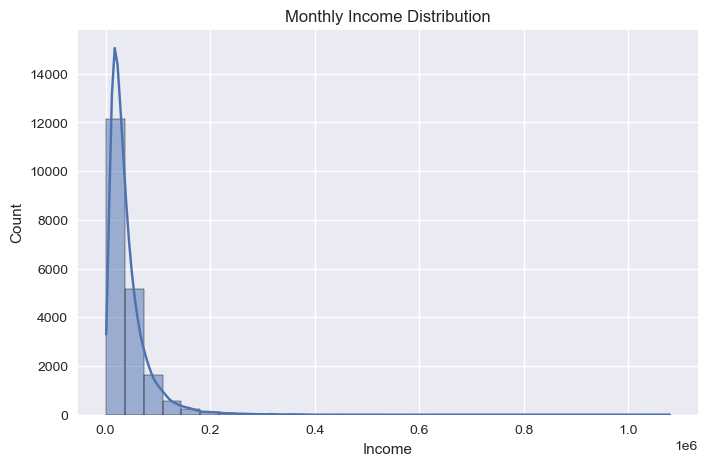

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["income"], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

##### Relationship Between Income and Savings

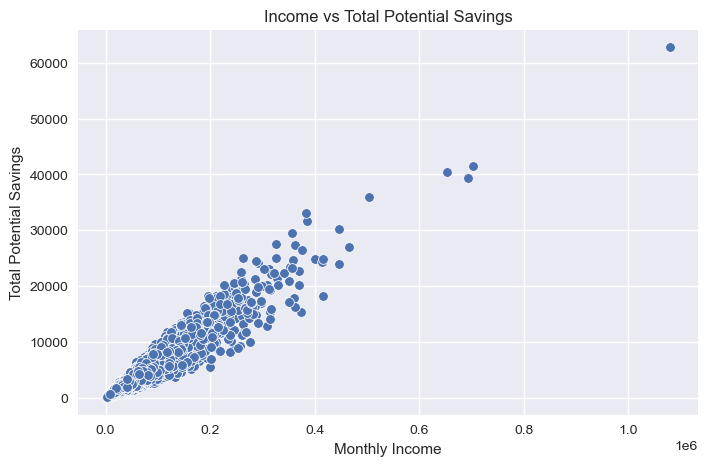

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create figures folder if not exists
os.makedirs("outputs/figures", exist_ok=True)

potential_cols = [
    "potential_savings_groceries",
    "potential_savings_transport",
    "potential_savings_eating_out",
    "potential_savings_entertainment",
    "potential_savings_utilities",
    "potential_savings_healthcare",
    "potential_savings_education",
    "potential_savings_miscellaneous"
]

df["total_potential_savings"] = df[potential_cols].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["income"],
    y=df["total_potential_savings"]
)

plt.title("Income vs Total Potential Savings")
plt.xlabel("Monthly Income")
plt.ylabel("Total Potential Savings")

# 🔹 SAVE FIGURE
plt.savefig(
    "outputs/figures/income_vs_total_potential_savings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Savings by city tire

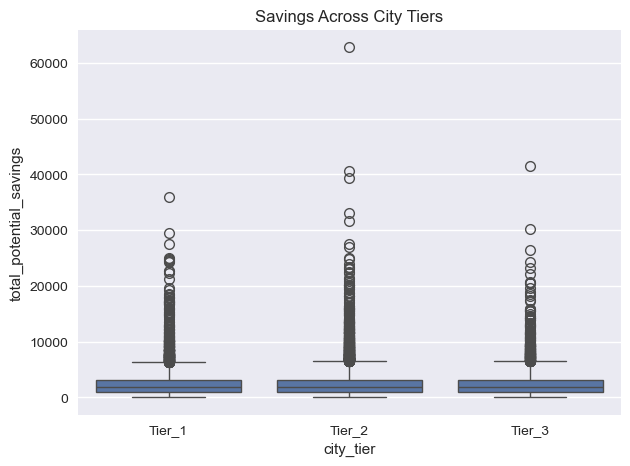

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x="city_tier", y="total_potential_savings", data=df)
plt.title("Savings Across City Tiers")
plt.show()

### Key Observations

- Higher income generally leads to higher savings.
- City tier has a noticeable impact on spending and savings patterns.
- The dataset shows diverse financial behaviors suitable for clustering.